## Ejemplo práctico: Entrenamiento del modelo

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Crear datos de ejemplo
datos = pd.DataFrame({
    "Horas_Estudio": [1, 2, 3, 4, 5],
    "Calificacion":  [45, 50, 65, 70, 85]
})

# 2) Separar variables
X = datos[["Horas_Estudio"]]
y = datos["Calificacion"]

# 3) Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# 4) Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5) Ver coeficientes del modelo
print("Intercepto (β0):", modelo.intercept_)
print("Coeficiente (β1):", modelo.coef_[0])

# 6) Predicción
y_pred = modelo.predict(X_test)

# 7) Métricas: R² (explícito) y MAE
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nR² (calculado con y_real vs y_pred):", r2)
print("MAE:", mae)

Intercepto (β0): 37.14285714285715
Coeficiente (β1): 8.57142857142857

R² (calculado con y_real vs y_pred): 0.9291961682632236
MAE: 4.642857142857146


In [ ]:
# 8) Realizar predicción para 3.5 horas de estudio
horas_nuevas = pd.DataFrame({"Horas_Estudio": [6]})
calificacion_predicha = modelo.predict(horas_nuevas)
print(f"Calificación predicha para 6 horas: {calificacion_predicha[0]:.2f}")

Calificación predicha para 6 horas: 88.57


## Live Coding 1

1. Generar y Cargar dataset (auto-mpg.csv)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

cols_num = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

# Lee 8 columnas por espacios + todo lo demás como el nombre (puede venir con espacios)
df = pd.read_csv(
    url,
    sep=r"\s+",
    names=cols_num + ["car_name"],
    na_values="?",
    engine="python",
    usecols=list(range(9)),          # asegura 9 columnas: 8 + 1 (resto)
    skipinitialspace=True
)

# Limpieza extra: quitar comillas si aparecen
df["car_name"] = df["car_name"].astype(str).str.strip().str.strip('"')

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford


| Campo         | Tipo (en df.info) | ¿Qué representa? | Unidad / valores típicos | Nota rápida |
|--------------|-------------------|------------------|--------------------------|-------------|
| mpg          | float64           | Eficiencia de combustible | millas/galón | **Target**: más alto = más eficiente |
| cylinders    | int64             | Nº de cilindros del motor | 3, 4, 5, 6, 8 | Más cilindros suele bajar mpg |
| displacement | float64           | Tamaño del motor (cilindrada) | pulgadas cúbicas (cu in) | Motor más grande suele bajar mpg |
| horsepower   | float64           | Potencia del motor | HP | Tiene **6 nulos** en tu df |
| weight       | float64           | Peso del vehículo | libras (lb) | Más peso suele bajar mpg |
| acceleration | float64           | Aceleración (tiempo) | segundos (0–60 mph aprox.) | Menor tiempo = más rápido |
| model_year   | int64             | Año del modelo | 70–82 | Autos más nuevos tienden a ser más eficientes |
| origin       | int64             | Origen del auto | 1=USA, 2=Europa, 3=Japón | En ML conviene tratarlo como categórica |
| car_name     | object            | Nombre/modelo del auto | texto | Usualmente se elimina o se procesa aparte |

Vamos a construir e interpretar un modelo de regresión lineal que predice el consumo de combustible (MPG) a partir del peso del vehículo.


En términos técnicos:
* Variable objetivo (y): mpg
* Variable predictora (X): weight

Sabemos, casi por física básica, que:

Más peso → más energía necesaria → más combustible → menor MPG

Entonces esperamos que el coeficiente β₁ sea:
* Negativo
* Estadísticamente coherente
* Interpretable

2. Inspeccionar variables y limpiar valores faltantes


In [2]:
df.shape

(398, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


3. Dividir en variables predictoras (X) y objetivo (y)

In [5]:
X = df[["weight"]]
y = df["mpg"]

4. Separar en train y test (80/20)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Entrenar con LinearRegression()

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
print("Intercepto:", model.intercept_)
print("Coeficiente (peso):", model.coef_[0])

Intercepto: 46.78206336645047
Coeficiente (peso): -0.00780524235159488


6. Visualizar recta de regresión

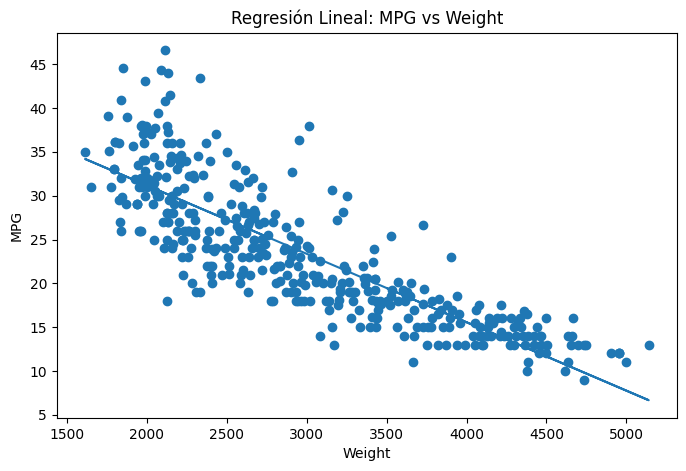

In [9]:
y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X, y) # dibuja puntos
plt.plot(X, y_pred) # dibuja una línea (conecta puntos en orden)
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Regresión Lineal: MPG vs Weight")
plt.show()

¿Qué observan?
¿La relación parece lineal?

1. Relación claramente negativa: A mayor peso → menor MPG
    Eso ya valida la intuición física.

2. La relación parece bastante lineal: No vemos una curva clara.
    La tendencia dominante es lineal decreciente.

3. Hay dispersión alrededor de la recta
   * Peso explica parte del MPG
   * pero claramente no todo.

7. Evaluar con R² y MAE

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error

y_test_pred = model.predict(X_test)

r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

print("R2:", r2)
print("MAE:", mae)

R2: 0.722971057303075
MAE: 3.1177861992064573


8. Interpretar el coeficiente de regresión

* ¿Qué significa R² = 0.72?
    El modelo explica aproximadamente el 72% de la variabilidad del MPG usando solo el peso.
    
    El peso es un predictor fuerte del consumo, pero no lo explica todo.

* ¿Qué significa MAE = 3.12?

    En promedio, el modelo se equivoca en:≈ 3.1 millas por galón.

* ¿Ese error es grande o pequeño? ... Depende del contexto.


In [11]:
df["mpg"].describe()

,mpg
count,398.000000
mean,23.514573
std,7.815984
min,9.000000
25%,17.500000
50%,23.000000
75%,29.000000
max,46.600000


In [12]:
3.1/(46.6-9)

0.08244680851063829

En promedio el modelo se equivoca alrededor de un 8% del rango observado.


In [13]:
3.1/23.5

0.13191489361702127

9. Aplicamos Cross-Validation (k=5)

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

# Validación cruzada con 5 folds
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 promedio:", np.mean(r2_scores))
print("Desviación estándar:", np.std(r2_scores))

R2 por fold: [ 0.43423842  0.35261673  0.79584633  0.68501427 -0.7082704 ]
R2 promedio: 0.31188907099100305
Desviación estándar: 0.5349374725542038


Primero: Tu split 80/20 dio R² ≈ 0.72.

Pero la validación cruzada dice:

* R² promedio ≈ 0.31
* Desviación estándar ≈ 0.53
* Un fold con R² negativo (-0.70)
(R² negativo significa:El modelo predice peor que simplemente usar la media.)

**Interpretación**

* El modelo no es estable.

* Funciona bien en algunos subconjuntos, pero muy mal en otros.

Eso puede indicar:
1. Alta sensibilidad a la distribución de los datos
2. Posible heterogeneidad en el dataset
3. Relación no perfectamente lineal
4. Que el train/test 80/20 fue “optimista”

Un solo split puede engañar.

La validación cruzada revela estabilidad o fragilidad.

Un modelo puede verse sólido en un split, pero inestable cuando se evalúa de forma más rigurosa.

10. K-Fold Cross Validation (Usa KFold con shuffle=True)

In [15]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42) # shuffle=True → mezcla las filas antes de dividir en folds.

r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print(r2_scores)
print("Promedio:", r2_scores.mean())
print("Std:", r2_scores.std())

[0.72297106 0.68883619 0.69029271 0.66528104 0.68379237]
Promedio: 0.690234672169334
Std: 0.018643054021819355


¿Qué pasó entonces?

Antes se uso KFold sin shuffle=True.

Eso significa que el dataset se dividió por bloques, respetando el orden original.

Y este dataset está ordenado por año/modelo.

Entonces probablemente ocurrió algo como esto:

* Fold 1 → autos antiguos
* Fold 2 → mezcla
* Fold 3 → más nuevos
* Fold 4 → otra mezcla
* Fold 5 → extremos

Eso rompe la homogeneidad entre folds.

No porque el dataset esté estratificado. Sino porque está ordenado.

El problema no era el modelo.

Era la forma en que dividimos los datos.

Cuando se activo shuffle=True:

* Las observaciones se distribuyeron aleatoriamente
* Cada fold tuvo mezcla representativa
* El rendimiento se estabilizó

Y ahora el promedio (0.69) está muy cerca del 80/20 original (~0.72).

Eso es coherente.

10. Conclusiones

La regresión lineal simple utilizando únicamente el peso del vehículo como predictor logra explicar aproximadamente el 69% de la variabilidad del MPG, y lo hace de forma estable cuando se evalúa mediante validación cruzada con barajado de datos. Esto confirma que el peso es un factor estructuralmente relevante en la eficiencia de combustible, aunque no la explica por completo. Además, la comparación entre distintos esquemas de validación demuestra que la forma en que dividimos los datos influye directamente en la percepción del desempeño del modelo. En consecuencia, no solo importa el algoritmo, sino también la estrategia de evaluación utilizada para estimar su capacidad de generalización.

El modelo simple MPG ~ Weight:

* Tiene R² ≈ 0.69 en promedio
* Es estable (std ≈ 0.018 es muy bajo)
* Generaliza razonablemente bien

## Ejercicio 1

1. Cargar el dataset bicicletas.csv



In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 250

peso = np.random.normal(12, 1.5, n)  # kg
tamano_cuadro = np.random.choice(["S", "M", "L"], n)
marchas = np.random.choice([7, 14, 18, 21, 24], n)
tipo = np.random.choice(["Ruta", "Montaña", "Urbana"], n)

# Relación de precio simulada
precio = (
    300
    + peso * -20
    + marchas * 25
    + np.where(tipo == "Montaña", 400, 0)
    + np.where(tipo == "Ruta", 600, 0)
    + np.random.normal(0, 150, n)
)

df = pd.DataFrame({
    "precio": precio.round(2),
    "peso": peso.round(2),
    "tamano_cuadro": tamano_cuadro,
    "marchas": marchas,
    "tipo": tipo
})

df.head()

,precio,peso,tamano_cuadro,marchas,tipo
0,965.69,12.75,S,21,Ruta
1,527.46,11.79,S,14,Montaña
2,880.49,12.97,S,21,Montaña
3,1108.64,14.28,S,21,Montaña
4,1005.50,11.65,L,24,Urbana


In [17]:
df.shape

(250, 5)

2. Explorar y limpiar los datos si es necesario

In [18]:
df["tipo"].value_counts()

,count
tipo,
Ruta,89
Urbana,83
Montaña,78


In [19]:
df["tamano_cuadro"].value_counts()

,count
tamano_cuadro,
S,103
L,75
M,72


In [20]:
df.isnull().sum()

,0
precio,0
peso,0
tamano_cuadro,0
marchas,0
tipo,0


3. Definir X (variables predictoras) & y (precio)

In [21]:
X = df.drop("precio", axis=1)
y = df["precio"]

In [22]:
X.head()

,peso,tamano_cuadro,marchas,tipo
0,12.75,S,21,Ruta
1,11.79,S,14,Montaña
2,12.97,S,21,Montaña
3,14.28,S,21,Montaña
4,11.65,L,24,Urbana


4. Separar en conjunto de entrenamiento y prueba

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Entrenar el modelo con LinearRegression

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

num_cols = ["peso", "marchas"]
cat_cols = ["tamano_cuadro", "tipo"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols) # drop="first" De cada grupo de categorías, una se elimina y se convierte en referencia.
    # Para evitar problemas de colinealidad.
])
#Pipeline significa:
# Paso 1 → Transformar
# Paso 2 → Entrenar modelo
model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression())
])

In [25]:
model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['peso', 'marchas']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['tamano_cuadro', 'tipo'])])),
                ('reg', LinearRegression())])

6. Obten e interpreta los coeficientes

In [26]:
coef = model.named_steps["reg"].coef_  # Extraer los coeficientes del modelo
feature_names = model.named_steps["prep"].get_feature_names_out() # Obtener los nombres reales de las variables
pd.Series(coef, index=feature_names).sort_values() # Unir coeficientes con nombres

,0
cat__tipo_Urbana,-388.003726
num__peso,-32.086484
cat__tamano_cuadro_M,27.132087
cat__tamano_cuadro_S,37.058243
num__marchas,154.702662
cat__tipo_Ruta,200.173521


In [27]:
intercepto = model.named_steps["reg"].intercept_
print("Intercepto:", intercepto)

Intercepto: 867.5364104464765


7. Realiza predicciones sobre el set de prueba

In [28]:
y_pred = model.predict(X_test)

8. Evalúa el rendimiento con R² y MAE

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)

R2: 0.7656410376806493
MAE: 126.17784347474709


9. Visualiza precios reales v/s predichos

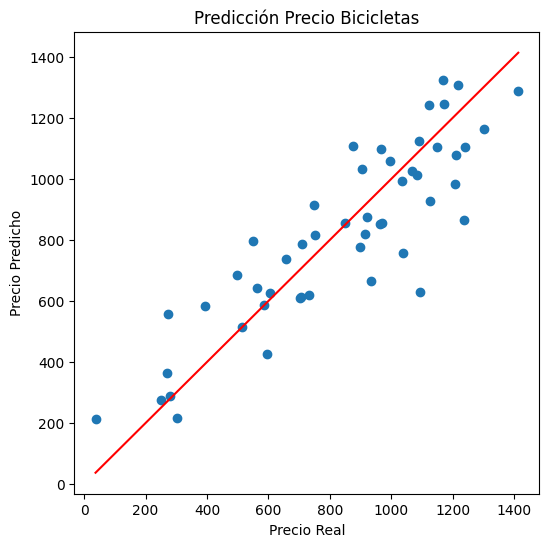

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Predicción Precio Bicicletas")
plt.show()

10. Reflexión: ¿el modelo es útil para el negocio?

R² = 0.756

Eso significa que el modelo explica aproximadamente el 75.6% de la variabilidad del precio.

En términos simples:

El 75% del comportamiento del precio se puede explicar por peso, marchas, tipo y tamaño.

MAE = 126.17

Aquí está lo realmente interesante.

El MAE es el error promedio absoluto.

Eso significa:

En promedio, te equivocas en aproximadamente 126 unidades monetarias.

**¿Es 126 mucho o poco?**

In [ ]:
y.min(), y.max()

(37.07, 1634.96)

Rango de precios:
1634.96 - 37.07 = 1597.89

Error promedio:
126.18

proporción del rango total : 126.18/1597.89 = 0.079 => 7.9%

In [ ]:
y.mean()

np.float64(829.96204)

126.18 / 829.96 = 15.20%

En promedio, el modelo se equivoca en 15% del precio promedio.



11. Validación Cruzada

In [32]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print("R2 por fold:", r2_scores)
print("R2 promedio:", np.mean(r2_scores))
print("Desviación estándar:", np.std(r2_scores))

R2 por fold: [0.76564104 0.83433052 0.66197539 0.76432911 0.73154396]
R2 promedio: 0.7515640052638863
Desviación estándar: 0.055925538302233915


1. El promedio es casi igual al R² que se obtuvo antes (~0.75).
Eso significa que el train/test inicial no fue suerte.

2. No hay ningún fold negativo.
Eso es buena señal. El modelo generaliza.

3. La desviación estándar es baja (~0.056).
Eso indica estabilidad. No está cambiando dramáticamente según la partición.

In [33]:
mae_scores = -cross_val_score(
    model, X, y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

print("MAE por fold:", mae_scores)
print("MAE promedio:", np.mean(mae_scores))
print("Desviación estándar:", np.std(mae_scores))

MAE por fold: [126.17784347 116.62049016 147.74479912 136.32672611 125.76081259]
MAE promedio: 130.52613429321212
Desviación estándar: 10.63120074528169


1. El error es consistente

La desviación estándar (~10)

 es baja respecto al promedio (~130).

Eso significa:

* El modelo no se comporta dramáticamente distinto según la partición.
* Es estable.

2. El error relativo sigue siendo ~15%

Recordando que el precio promedio era ~830.
* 130/830≈15.6%

Eso confirma lo que ya habíamos visto.

El modelo predice con un error promedio cercano al 15%.

3. Fold 3 tuvo mayor error (~147)

* Pero no es extremo.
* No hay fold donde el error se dispare.
* Eso es buena señal de generalización.

**Conclusión global**

El modelo de regresión lineal múltiple logra explicar aproximadamente el 75% de la variabilidad del precio de las bicicletas y lo hace de manera estable bajo validación cruzada, lo que confirma que no depende de una partición específica de los datos. El error promedio se sitúa en torno a 130 unidades monetarias, equivalente a cerca del 15% del precio promedio, lo que indica que el modelo captura bien la estructura general del problema, aunque aún existe variabilidad no explicada. En términos prácticos, el modelo es útil para estimaciones razonables y análisis comparativos, pero podría perfeccionarse incorporando variables adicionales o técnicas más complejas si se requiere mayor precisión.

## PARTE 2

## Análisis de residuos

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Crear datos de ejemplo
datos = pd.DataFrame({
    "Horas_Estudio": [1, 2, 3, 4, 5],
    "Calificacion":  [45, 50, 65, 70, 85]
})

# 2) Separar variables
X = datos[["Horas_Estudio"]]
y = datos["Calificacion"]

# 3) Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# 4) Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5) Ver coeficientes del modelo
print("Intercepto (β0):", modelo.intercept_)
print("Coeficiente (β1):", modelo.coef_[0])

# 6) Predicción
y_pred = modelo.predict(X_test)

# 7) Métricas: R² (explícito) y MAE
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nR² (calculado con y_real vs y_pred):", r2)
print("MAE:", mae)

Intercepto (β0): 37.14285714285715
Coeficiente (β1): 8.57142857142857

R² (calculado con y_real vs y_pred): 0.9291961682632236
MAE: 4.642857142857146


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predicciones sobre TODO el dataset (más pedagógico que solo test)
y_pred_total = modelo.predict(X)

# Calcular residuos
residuos = y - y_pred_total

# Crear DataFrame para visualizar
df_res = pd.DataFrame({
    "Horas_Estudio": X["Horas_Estudio"],
    "y_real": y,
    "y_pred": y_pred_total,
    "residuo": residuos
})

print(df_res)

   Horas_Estudio  y_real     y_pred   residuo
0              1      45  45.714286 -0.714286
1              2      50  54.285714 -4.285714
2              3      65  62.857143  2.142857
3              4      70  71.428571 -1.428571
4              5      85  80.000000  5.000000


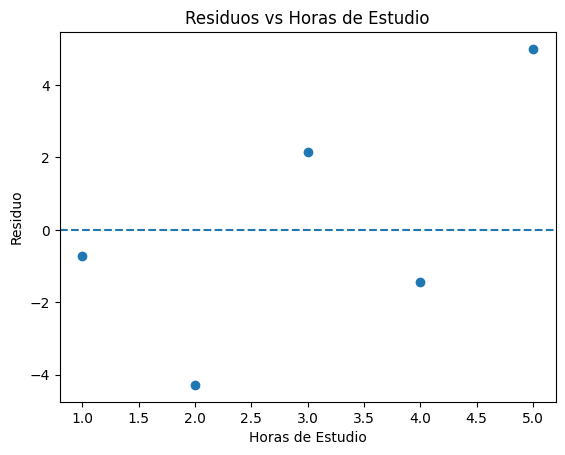

In [ ]:
plt.scatter(X, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Horas de Estudio")
plt.ylabel("Residuo")
plt.title("Residuos vs Horas de Estudio")
plt.show()

## Ejemplo práctico: Comparación de modelos

In [ ]:
# Comparación de modelos
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

# Modelo lineal
modelo_lineal = LinearRegression()
mse_lineal = -cross_val_score(modelo_lineal, X, y, cv=5, scoring='neg_mean_squared_error')

# Modelo polinómico
modelo_poli = Pipeline([    ('poly', PolynomialFeatures(degree=2)),
                            ('linear', LinearRegression())])
mse_poli = -cross_val_score(modelo_poli, X, y, cv=5, scoring='neg_mean_squared_error')


print(f"MSE modelo lineal: {np.mean(mse_lineal):.2f}")
print(f"MSE modelo polinómico: {np.mean(mse_poli):.2f}")

MSE modelo lineal: 18.60
MSE modelo polinómico: 24.18


## Ejemplo Regresión lineal simple

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Datos ficticios
datos = pd.DataFrame({
    "Publicidad_millones": [1, 2, 3, 4, 5, 6],
    "Ventas_millones":      [15, 18, 25, 28, 35, 40]
})

X = datos[["Publicidad_millones"]]
y = datos["Ventas_millones"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto (β0):", modelo.intercept_)
print("Pendiente (β1):", modelo.coef_[0])

Intercepto (β0): 8.933333333333326
Pendiente (β1): 5.114285714285716


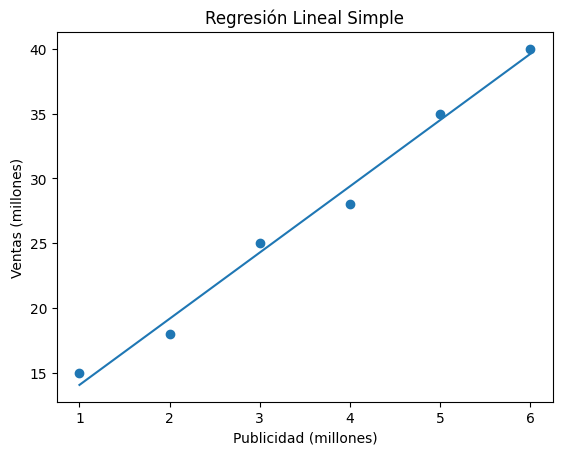

In [ ]:
y_pred = modelo.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Publicidad (millones)")
plt.ylabel("Ventas (millones)")
plt.title("Regresión Lineal Simple")
plt.show()

In [ ]:
# 7) Métricas: R² (explícito) y MAE
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("\nR² (calculado con y_real vs y_pred):", r2)
print("MAE:", mae)


R² (calculado con y_real vs y_pred): 0.9889706260610114
MAE: 0.850793650793651


In [ ]:
nueva_inversion = pd.DataFrame({"Publicidad_millones": [10]})
venta_estimada = modelo.predict(nueva_inversion)
print(f"Ventas esperadas para 7 millones en publicidad: {venta_estimada[0]:.2f}")

Ventas esperadas para 7 millones en publicidad: 60.08


## Regresión lineal múltiple

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Datos de ejemplo (casas) ---
np.random.seed(42)
n = 80

Metros2 = np.random.randint(40, 220, n)
Habitaciones = np.clip((Metros2 / 40).round().astype(int), 1, 6)
Antiguedad = np.random.randint(0, 40, n)

Precio = 20 + 1.2*Metros2 + 12*Habitaciones - 1.5*Antiguedad + np.random.normal(0, 15, n)

datos = pd.DataFrame({
    "Metros2": Metros2,
    "Habitaciones": Habitaciones,
    "Antiguedad": Antiguedad,
    "Precio": Precio
})


X = datos[["Metros2", "Habitaciones", "Antiguedad"]]
y = datos["Precio"]

# 1) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) Pipeline (escalado + modelo)
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# 3) Entrenar
pipe.fit(X_train, y_train)

# 4) Predecir y evaluar
y_pred = pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# 5) Ver coeficientes (OJO: son sobre variables escaladas)
modelo_lr = pipe.named_steps["model"]
print("Intercepto:", modelo_lr.intercept_)
print("Coeficientes (sobre X escalada):", modelo_lr.coef_)

# 6) Predicción nueva (sin warning, con nombres correctos)
nueva_casa = pd.DataFrame({
    "Metros2": [110],
    "Habitaciones": [3],
    "Antiguedad": [7]
})

precio_estimado = pipe.predict(nueva_casa)
print("Precio estimado:", precio_estimado[0])

R²: 0.951
MAE: 12.376
RMSE: 16.159
Intercepto: 174.42237342996933
Coeficientes (sobre X escalada): [ 68.31814267  10.92255691 -20.76831983]
Precio estimado: 177.25065492775016


In [ ]:
precio_estimado = pipe.predict(nueva_casa)
print("Precio estimado:", precio_estimado)

Precio estimado: [177.25065493]


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, y, cv=3, scoring="r2")
print("R² promedio CV:", scores.mean())

R² promedio CV: 0.9641425912489451


## Ejemplo: Regresión polinómica

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos simulados
temperatura = np.array([5, 8, 12, 15, 18, 22, 25, 30, 35])
consumo = np.array([300, 250, 200, 180, 170, 190, 220, 280, 350])

datos = pd.DataFrame({
    "Temperatura": temperatura,
    "Consumo": consumo
})
datos

,Temperatura,Consumo
0,5,300
1,8,250
2,12,200
3,15,180
4,18,170
5,22,190
6,25,220
7,30,280
8,35,350


In [ ]:
from sklearn.linear_model import LinearRegression

X = datos[["Temperatura"]]
y = datos["Consumo"]

modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

y_pred_lineal = modelo_lineal.predict(X)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

modelo_polinomico = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])

modelo_polinomico.fit(X, y)
y_pred_poly = modelo_polinomico.predict(X)

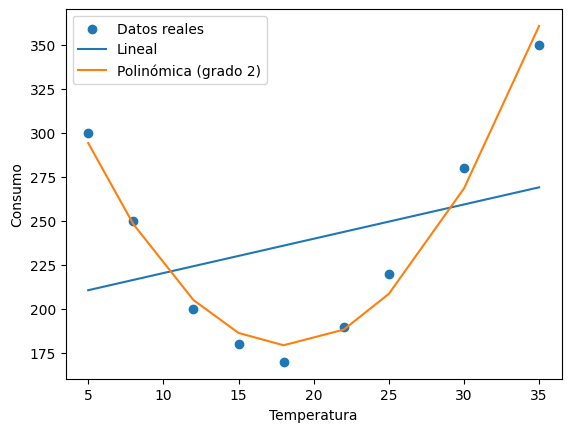

In [ ]:
plt.scatter(X, y, label="Datos reales")
plt.plot(X, y_pred_lineal, label="Lineal")
plt.plot(X, y_pred_poly, label="Polinómica (grado 2)")
plt.xlabel("Temperatura")
plt.ylabel("Consumo")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

print("R² Lineal:", r2_score(y, y_pred_lineal))
print("R² Polinómica:", r2_score(y, y_pred_poly))

R² Lineal: 0.10059928426655707
R² Polinómica: 0.9810530356367204


## Regresión Ridge

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

datos = pd.DataFrame({
    "Metros2": [60, 80, 100, 120, 150, 200, 220, 250],
    "Habitaciones": [2, 2, 3, 3, 4, 5, 5, 6],
    "Antiguedad": [20, 15, 10, 8, 5, 2, 1, 1],
    "Precio": [90, 120, 150, 170, 210, 300, 330, 380]
})

X = datos[["Metros2", "Habitaciones", "Antiguedad"]]
y = datos["Precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
from sklearn.linear_model import Ridge

modelo_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

modelo_ridge.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
y_pred = modelo_ridge.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("MAE:", mae)

R²: 0.9895671776214642
MAE: 6.615604328924661


In [ ]:
ridge_model = modelo_ridge.named_steps["ridge"]

print("Intercepto:", ridge_model.intercept_)
print("Coeficientes Ridge:", ridge_model.coef_)

Intercepto: 221.66666666666666
Coeficientes Ridge: [ 42.71151489  38.7643404  -14.4756203 ]


## Regresión Lasso

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Dataset ampliado
datos = pd.DataFrame({
    "Metros2": [60, 80, 100, 120, 150, 200, 220, 250],
    "Habitaciones": [2, 2, 3, 3, 4, 5, 5, 6],
    "Antiguedad": [20, 15, 10, 8, 5, 2, 1, 1],
    "DistanciaMetro": [800, 600, 400, 300, 200, 150, 100, 80],
    "ColorCasa": [1, 0, 1, 1, 0, 1, 0, 1],  # variable irrelevante ficticia
    "Precio": [90, 120, 150, 170, 210, 300, 330, 380]
})

X = datos.drop(columns="Precio")
y = datos["Precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
modelo_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.5))
])

modelo_lasso.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.5))])

In [ ]:
y_pred = modelo_lasso.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.994806986707303


In [ ]:
lasso_model = modelo_lasso.named_steps["lasso"]

coeficientes = pd.Series(
    lasso_model.coef_,
    index=X.columns
)

print(coeficientes)

Metros2           105.261554
Habitaciones        0.499610
Antiguedad          0.000000
DistanciaMetro      4.172614
ColorCasa           2.796938
dtype: float64


## Regresión ElasticNet

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

datos = pd.DataFrame({
    "Metros2": [60, 80, 100, 120, 150, 200, 220, 250],
    "Habitaciones": [2, 2, 3, 3, 4, 5, 5, 6],
    "Antiguedad": [20, 15, 10, 8, 5, 2, 1, 1],
    "DistanciaMetro": [800, 600, 400, 300, 200, 150, 100, 80],
    "ColorCasa": [1, 0, 1, 1, 0, 1, 0, 1],  # ruido
    "Precio": [90, 120, 150, 170, 210, 300, 330, 380]
})

X = datos.drop(columns="Precio")
y = datos["Precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
modelo_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.5, l1_ratio=0.5))
])

modelo_elastic.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('elastic', ElasticNet(alpha=0.5))])

In [ ]:
y_pred = modelo_elastic.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.9863732609327055


In [ ]:
elastic_model = modelo_elastic.named_steps["elastic"]

coeficientes = pd.Series(
    elastic_model.coef_,
    index=X.columns
)

print(coeficientes)

Metros2           37.821505
Habitaciones      35.179775
Antiguedad       -13.704158
DistanciaMetro    -8.314941
ColorCasa          2.136076
dtype: float64


## Regresión con árboles de decisión

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

temperatura = np.array([5, 8, 12, 15, 18, 22, 25, 30, 35])
consumo = np.array([300, 250, 200, 180, 170, 190, 220, 280, 350])

datos = pd.DataFrame({
    "Temperatura": temperatura,
    "Consumo": consumo
})

X = datos[["Temperatura"]]
y = datos["Consumo"]

In [ ]:
from sklearn.tree import DecisionTreeRegressor

modelo_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_tree.fit(X, y)

y_pred_tree = modelo_tree.predict(X)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R²:", r2_score(y, y_pred_tree))
print("MAE:", mean_absolute_error(y, y_pred_tree))

R²: 0.9835285505124451
MAE: 4.444444444444445


## Random Forest para regresión

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

temperatura = np.array([5, 8, 12, 15, 18, 22, 25, 30, 35])
consumo = np.array([300, 250, 200, 180, 170, 190, 220, 280, 350])

datos = pd.DataFrame({
    "Temperatura": temperatura,
    "Consumo": consumo
})

X = datos[["Temperatura"]]
y = datos["Consumo"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

modelo_rf.fit(X, y)

RandomForestRegressor(max_depth=4, random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = modelo_rf.predict(X)

print("R²:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

R²: 0.9369255615849196
MAE: 10.584259259259259


## Gradient Boosting para regresión

Tiempo de entrega vs Distancia

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

distancia = np.linspace(1, 20, 500)
tiempo = 2 * distancia + 0.5 * distancia**2 + np.random.normal(0, 10, 500)

datos = pd.DataFrame({
    "Distancia": distancia,
    "Tiempo": tiempo
})

X = datos[["Distancia"]]
y = datos["Tiempo"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = GradientBoostingRegressor(
    n_estimators=200, # Número de árboles que se van a construir secuencialmente.
    learning_rate=0.1, # Controla cuánto peso tiene cada árbol nuevo en la predicción final.
    max_depth=3, # Controla la profundidad de cada árbol individual.
    random_state=42 # Solo fijea la semilla: No cambie cada vez que ejecutes el código.
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_gb.fit(X_train, y_train)


GradientBoostingRegressor(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = modelo_gb.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.97897222593892
MAE: 8.797437039694067


## Support Vector Regression (SVR)

Relación no lineal (Distancia vs Tiempo)

Usaremos una relación ligeramente curva.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(1, 20, 50)
y = 2 * X + 0.5 * X**2 + np.random.normal(0, 8, 50)

datos = pd.DataFrame({
    "Distancia": X,
    "Tiempo": y
})

X = datos[["Distancia"]]
y = datos["Tiempo"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

modelo_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, epsilon=5))
])

modelo_svr.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100, epsilon=5))])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = modelo_svr.predict(X)

print("R²:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

R²: 0.9890909853463183
MAE: 5.898897115436248


## Redes neuronales para regresión

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(1, 20, 80)
y = 2 * X + 0.5 * X**2 + np.random.normal(0, 10, 80)

datos = pd.DataFrame({
    "Distancia": X,
    "Tiempo": y
})

X = datos[["Distancia"]]
y = datos["Tiempo"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

modelo_nn = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(50, 50),
        activation="relu",
        solver="adam",
        max_iter=5000,
        random_state=42
    ))
])

modelo_nn.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=5000,
                              random_state=42))])

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = modelo_nn.predict(X)

print("R²:", r2_score(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

R²: 0.9851458984136756
MAE: 7.195842258731392


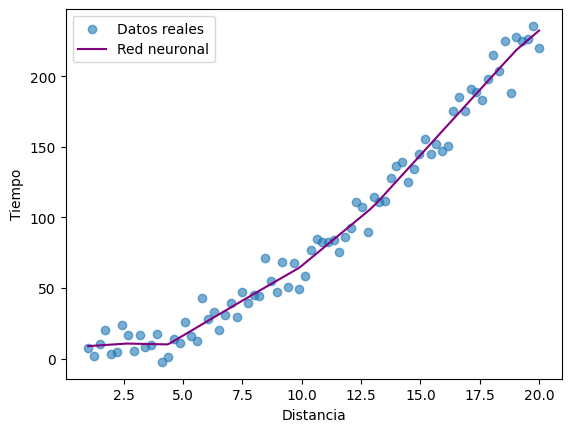

In [ ]:
X_smooth = pd.DataFrame(
    np.linspace(X.min().values[0], X.max().values[0], 200),
    columns=["Distancia"]
)

y_smooth = modelo_nn.predict(X_smooth)

plt.scatter(X, y, alpha=0.6, label="Datos reales")
plt.plot(X_smooth, y_smooth, color="purple", label="Red neuronal")
plt.xlabel("Distancia")
plt.ylabel("Tiempo")
plt.legend()
plt.show()

## Regresión con series temporales

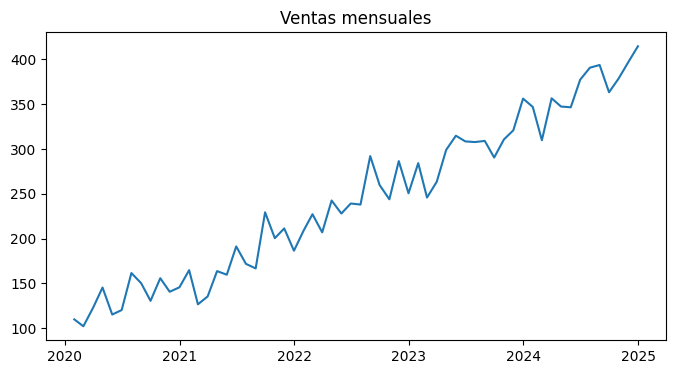

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

fechas = pd.date_range(start="2020-01-01", periods=60, freq="ME")
ventas = 100 + np.arange(60)*5 + np.random.normal(0, 20, 60)

datos = pd.DataFrame({
    "Fecha": fechas,
    "Ventas": ventas
})

datos.set_index("Fecha", inplace=True)

plt.figure(figsize=(8,4))
plt.plot(datos.index, datos["Ventas"])
plt.title("Ventas mensuales")
plt.show()

In [ ]:
datos["Tiempo"] = np.arange(len(datos))

In [ ]:
datos.head()

,Ventas,Tiempo
Fecha,,
2020-01-31,109.934283,0
2020-02-29,102.234714,1
2020-03-31,122.953771,2
2020-04-30,145.460597,3
2020-05-31,115.316933,4


In [ ]:
train = datos.iloc[:48]   # primeros 4 años
test = datos.iloc[48:]    # último año

X_train = train[["Tiempo"]]
y_train = train["Ventas"]

X_test = test[["Tiempo"]]
y_test = test["Ventas"]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

modelo_ts = LinearRegression()
modelo_ts.fit(X_train, y_train)

y_pred = modelo_ts.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.46836700162803746
MAE: 17.255788993908805


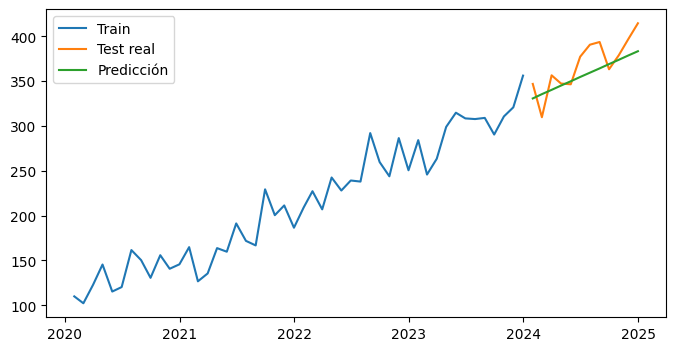

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Test real")
plt.plot(test.index, y_pred, label="Predicción")
plt.legend()
plt.show()

## Live Coding 2

**Paso 0 — Cargar dataset**

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Paso 1 — Preprocesamiento (Pipeline)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
])

pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])

**Paso 2 — Entrenar con Validación Cruzada**

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Linear": pipe_linear,
    "Ridge": pipe_ridge,
    "Polynomial": pipe_poly,
    "SVR": pipe_svr
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-scores.mean())
    print(f"{name} RMSE CV: {rmse:.4f}")

Linear RMSE CV: 0.7206
Ridge RMSE CV: 0.7206
Polynomial RMSE CV: 3.2324
SVR RMSE CV: 0.5661


**Paso 3 — Entrenar final y comparar métricas en Test**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


Linear
RMSE: 0.7455813830127763
MAE: 0.5332001304956565
R2: 0.575787706032451

Ridge
RMSE: 0.7455567442814779
MAE: 0.5331931195789733
R2: 0.5758157428913684

Polynomial
RMSE: 0.6813967448044699
MAE: 0.4670009334696575
R2: 0.6456819729261861

SVR
RMSE: 0.568943909879748
MAE: 0.37744526282679725
R2: 0.7529800406100791


**Paso 4 — Visualizar residuos**

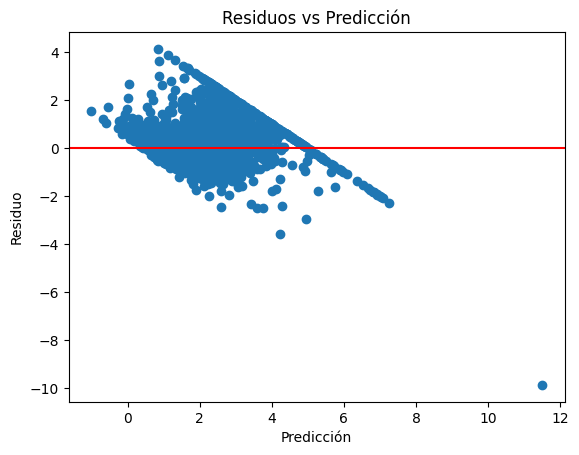

In [ ]:
import matplotlib.pyplot as plt

best_model = pipe_ridge
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos vs Predicción")
plt.show()

**Paso 5 — Regularización y comparación directa**

In [ ]:
from sklearn.linear_model import RidgeCV

ridge_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=[0.1, 1, 10, 100]))
])

ridge_cv.fit(X_train, y_train)
print("Mejor alpha:", ridge_cv.named_steps["model"].alpha_)

Mejor alpha: 1.0


**Paso 6 — SHAP**

/tmp/ipython-input-4142598742.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


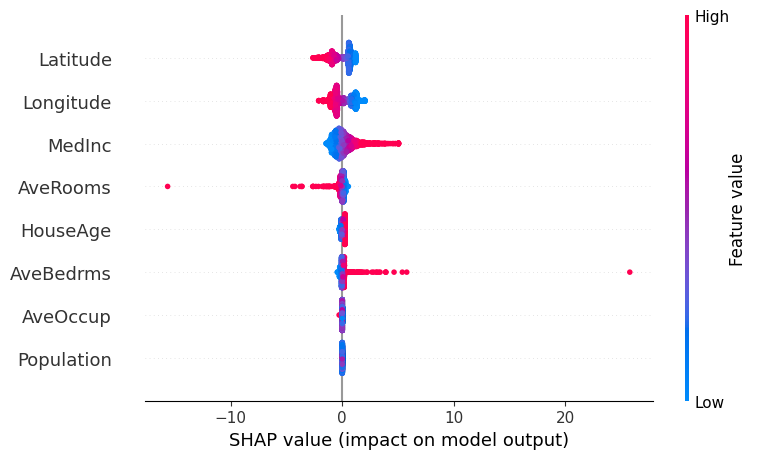

In [ ]:
import shap

pipe_ridge.fit(X_train, y_train)
explainer = shap.LinearExplainer(pipe_ridge.named_steps["model"],
                                  pipe_ridge.named_steps["scaler"].transform(X_train))
shap_values = explainer.shap_values(pipe_ridge.named_steps["scaler"].transform(X_test))

shap.summary_plot(shap_values, X_test)

**Paso 7 — Guardar modelo**

In [ ]:
import joblib

joblib.dump(pipe_ridge, "modelo_ridge.pkl")

['modelo_ridge.pkl']

**Paso 8 — Simular inferencia**

In [ ]:
modelo_cargado = joblib.load("modelo_ridge.pkl")
nueva_prediccion = modelo_cargado.predict(X_test.iloc[[0]])
print(nueva_prediccion)

[0.71947224]


***Un modelo no termina cuando lo evaluamos. Termina cuando puede vivir fuera del notebook.***

## Ejercicio

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1200
brands = ["Toyota","Hyundai","Kia","Chevrolet","Ford","Nissan","Mazda","Volkswagen","BMW","Audi"]
fuel = ["Gasolina","Diesel","Híbrido","Eléctrico"]
trans = ["Manual","Automática"]

year = np.random.randint(2005, 2025, n)
age = 2025 - year

km = (np.random.gamma(shape=2.2, scale=18000, size=n) + age*6000).astype(int)
km = np.clip(km, 0, 350000)

brand = np.random.choice(brands, n, p=[0.16,0.12,0.10,0.10,0.10,0.10,0.08,0.10,0.07,0.07])
fuel_type = np.random.choice(fuel, n, p=[0.72,0.12,0.10,0.06])
transmission = np.random.choice(trans, n, p=[0.45,0.55])

hp_base = {"Toyota":120,"Hyundai":110,"Kia":115,"Chevrolet":130,"Ford":140,"Nissan":125,"Mazda":135,"Volkswagen":145,"BMW":190,"Audi":200}
hp = np.array([hp_base[b] for b in brand]) + np.random.normal(0, 20, n)
hp = np.clip(hp, 70, 350).round(0)

# Precio base por marca + ajustes
brand_premium = {"Toyota":1.00,"Hyundai":0.88,"Kia":0.90,"Chevrolet":0.92,"Ford":0.95,"Nissan":0.93,"Mazda":0.97,"Volkswagen":1.02,"BMW":1.45,"Audi":1.50}
premium = np.array([brand_premium[b] for b in brand])

fuel_factor = {"Gasolina":1.00,"Diesel":1.05,"Híbrido":1.18,"Eléctrico":1.30}
ff = np.array([fuel_factor[f] for f in fuel_type])

trans_factor = {"Manual":0.97,"Automática":1.03}
tf = np.array([trans_factor[t] for t in transmission])

# Precio (en miles) con ruido + degradación por edad y km
price = (
    (18 + 0.08*hp) * premium * ff * tf
    - 0.55*age
    - 0.00003*km
    + np.random.normal(0, 2.2, n)
)

price = np.clip(price, 2.0, None)  # mínimo
price = (price*1000).round(0)      # a moneda (CLP/US$ da igual para demo)

df = pd.DataFrame({
    "anio": year,
    "marca": brand,
    "kilometraje": km,
    "combustible": fuel_type,
    "transmision": transmission,
    "potencia_hp": hp,
    "precio": price
})

# Inyectar nulos para practicar imputación
for col in ["potencia_hp", "combustible"]:
    mask = np.random.rand(n) < 0.03
    df.loc[mask, col] = np.nan

df.to_csv("autos.csv", index=False)
print("Listo: autos.csv guardado")
df.head()

Listo: autos.csv guardado


,anio,marca,kilometraje,combustible,transmision,potencia_hp,precio
0,2011,Toyota,90219,Diesel,Automática,134.0,25255.0
1,2024,Hyundai,76322,Eléctrico,Manual,75.0,23743.0
2,2019,Nissan,46477,Gasolina,Automática,127.0,22153.0
3,2015,Chevrolet,88337,Diesel,Automática,97.0,18774.0
4,2012,Chevrolet,135952,Diesel,Automática,80.0,15166.0


**Exploración rápida**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   anio         1200 non-null   int64  
 1   marca        1200 non-null   object 
 2   kilometraje  1200 non-null   int64  
 3   combustible  1167 non-null   object 
 4   transmision  1200 non-null   object 
 5   potencia_hp  1166 non-null   float64
 6   precio       1200 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 65.8+ KB


In [ ]:
df.isnull().sum()

,0
anio,0
marca,0
kilometraje,0
combustible,33
transmision,0
potencia_hp,34
precio,0


In [ ]:
df.describe()

,anio,kilometraje,potencia_hp,precio
count,1200.000000,1200.000000,1166.000000,1200.000000
mean,2014.174167,103547.896667,134.350772,21899.844167
std,5.924504,44506.904435,33.608214,10319.070911
min,2005.000000,10777.000000,70.000000,4088.000000
25%,2009.000000,69987.250000,110.000000,15000.250000
50%,2014.000000,103082.500000,129.000000,19662.500000
75%,2019.000000,133356.750000,151.000000,25019.250000
max,2024.000000,263162.000000,259.000000,64894.000000


**Separar variables**

In [ ]:
X = df.drop(columns="precio")
y = df["precio"]

**Definir columnas**

In [ ]:
numeric_cols = ["anio", "kilometraje", "potencia_hp"]
categorical_cols = ["marca", "combustible", "transmision"]

**Construir preprocesamiento**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

**Modelos**

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe_linear = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

pipe_ridge = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])

pipe_svr = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVR())
])

pipe_tree = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

**GridSearch**

In [ ]:
param_ridge = {
    "model__alpha": [0.1, 1, 10, 100]
}

param_svr = {
    "model__C": [1, 10],
    "model__epsilon": [0.1, 1]
}

grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=5, scoring="neg_mean_squared_error")
grid_svr = GridSearchCV(pipe_svr, param_svr, cv=5, scoring="neg_mean_squared_error")

**Train/Test split**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Entrenar modelos**

In [ ]:
models = {
    "Linear": pipe_linear,
    "Ridge": grid_ridge,
    "SVR": grid_svr,
    "Tree": pipe_tree
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

In [ ]:
pd.DataFrame(results).T

**Analizar residuos del mejor modelo**

In [ ]:
best_model = grid_ridge

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos vs Predicción")
plt.show()

**Importancia de variables (Árbol)**

In [ ]:
pipe_tree.fit(X_train, y_train)

importances = pipe_tree.named_steps["model"].feature_importances_

feature_names = pipe_tree.named_steps["preprocess"].get_feature_names_out()

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

imp_df.head(10)